<a href="https://colab.research.google.com/github/mohammedibrahimshawon/Computer_Vision_assignmentS26/blob/main/exercise_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision
## Exercise Sheet 1: Imaging
### Erhardt Barth / Christoph Linse / Manuel Laufer / Kathleen Anderson
Universität zu Lübeck, Institut für Neuro- und Bioinformatik

In case of questions, contact us via email: *{erhardt.barth, c.linse, m.laufer, k.anderson} @uni-luebeck.de*

## Note: Please insert the names of all participating students:

1. Shawon,Mohammed Ibrahim
2.
3.
4.
5.


In [18]:
import sys, os
if 'google.colab' in sys.modules:
  if os.getcwd() == '/content':
    !git clone 'https://github.com/inb-luebeck/cs4250.git'
    os.chdir('cs4250')

In [19]:
import cv2 # open cv
import matplotlib.pyplot as plt # plotting tools
import numpy as np # matrix, array operations

from os.path import join # combine different items to a path
from os import getcwd, listdir # shows the current directory, lists items in a directory

# show plots when running cell
%matplotlib inline

## Exercise 1.1
### Loading and displaying images in Python
Download the image `clown.png` from the website of the tutorial. Load
the image in Python via opencv (`cv2.imread`). By default the image is loaded as BGR (blue, green, red), convert the image to gray with `cv2.cvtColor`.
Display the image `plt.imshow`, use the colormap `gray`.

Current directory: /content/cs4250
['exercise_3', 'exercise_2', 'exercise_1', 'exercise_4', 'exercise_5']
Found image at: /content/cs4250/data/exercise_1/clown.png


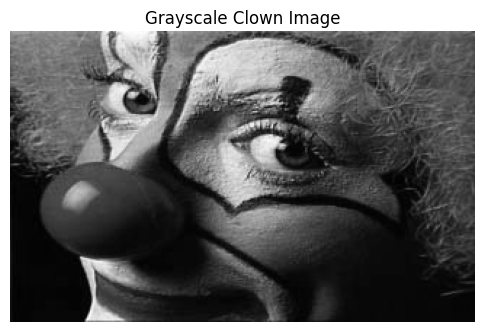

In [20]:
# TODO: define image path
from os import listdir, getcwd
from os.path import join

print("Current directory:", getcwd())

# Show files inside data folder
print(listdir(join(getcwd(), 'data')))
# TODO: read image
import cv2
import matplotlib.pyplot as plt
from os import walk, getcwd
from os.path import join

# Search for clown.png
for root, dirs, files in walk(getcwd()):
    if 'clown.png' in files:
        img_path = join(root, 'clown.png')
        print("Found image at:", img_path)

# Load image
img_bgr = cv2.imread(img_path)

# Convert to grayscale
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Display image
plt.figure(figsize=(6,6))
plt.imshow(img_gray, cmap='gray')
plt.title("Grayscale Clown Image")
plt.axis('off')
plt.show()
# TODO: convert image to grayscale

# TODO: display image


## Exercise 1.2
### Image gradients
Images are stored as `numpy arrays`, for further computations convert the array to range $[0, 1]$ (`astype`). Define a function `load_gray_normalized` that loads the image, converts it to grayscale and normalizes it.
Compute the image gradients $d_x$ and $d_y$ for the image from the previous assignment. Initialize a simple gradient kernel like $[-1, 0, +1]$ for $d_x$ (`np.zeros`, `np.array`) and filter the image with it (`cv2.filter2D`). Visualize the results using `plt.imshow`. To this end, display the resulting images of both derivatives along `x` and `y` in a single figure (`plt.subplots`).

What do you need to take care of, to be able to visually **compare** the results?
Hint: the problem is related to the range of the pixel values in the two
gradient images. Name the problem and propose a solution to it by using the options of the `plt.imshow`
function.

In [21]:
def load_gray_normalized(image_path):
    pass

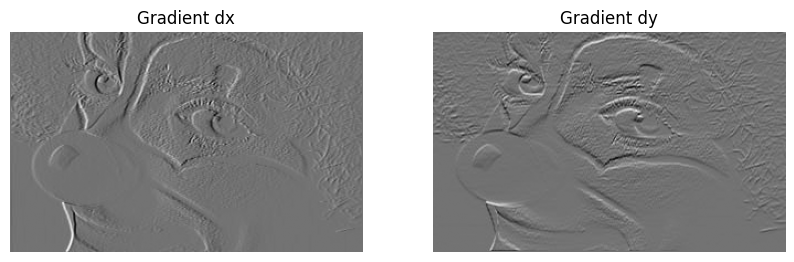

In [22]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
# urllib.request is no longer needed as the image is loaded locally

# The image is already available locally from the cloned repository
# url = "https://github.com/inb-luebeck/cs4250/raw/main/data/clown.png"
# urllib.request.urlretrieve(url, "clown.png")


def load_gray_normalized(image_path):

    # Load image
    img_bgr = cv2.imread(image_path)

    # Check if image loaded correctly
    if img_bgr is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    # Convert BGR -> Gray
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Normalize to range [0,1]
    img_gray = img_gray.astype(np.float32) / 255.0

    return img_gray


# Load image using the local path
img = load_gray_normalized("data/exercise_1/clown.png")


# Define gradient kernels
kernel_dx = np.array([[-1, 0, 1]], dtype=np.float32)

kernel_dy = np.array([
    [-1],
    [ 0],
    [ 1]
], dtype=np.float32)


# Filter image
dx = cv2.filter2D(img, -1, kernel_dx)
dy = cv2.filter2D(img, -1, kernel_dy)


# Common visualization range
vmin = min(dx.min(), dy.min())
vmax = max(dx.max(), dy.max())


# Display results
fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].imshow(dx, cmap='gray', vmin=vmin, vmax=vmax)
ax[0].set_title("Gradient dx")
ax[0].axis('off')

ax[1].imshow(dy, cmap='gray', vmin=vmin, vmax=vmax)
ax[1].set_title("Gradient dy")
ax[1].axis('off')

plt.show()

## Exercise 1.3
### Point operations
Download from the website the images `ueb131.png` and `ueb132.png`,
then load and display them.  
Both images illustrate two commonly encountered problems in photography.
Underexposed (overexposed) images are darker (brighter) than they should be,
because they have been exposed to too little (too much) light.

Compute and display the histograms (`plt.hist`,`np.flatten`) of the images in range $[0,1]$. Write a function `display_with_hist` that creates two subplots, showing the image and the respective histogram.

Can you identify the exposure problems in the histograms?
Hint: look at how the pixel intensities are distributed.

These defects can be corrected by remapping the pixel values to achieve a
more evenly distributed range of pixel intensities.
This can either be done by using histogram equalization (`cv2.equalizeHist`) or by using the logarithmic and power functions.

To use `cv2.equalizeHist`, the images need to be casted to uint8 in $[0,255]$. Write a function `normalized_to_uint8` to do this.

Apply the logarithmic and power to improve the two images. Experiment with different bases for the logarithm and power. To get a better feeling for the problem, plot the functions $x^2$ in $[0,1]$ and $log(x)$ in $[1,255]$ (why not $[0, 255]$?, `np.linspace, np.log, plt.plot`). **Where do the functions change quickly, where do they change slowly? How can you use this knowledge to improve the images?**

In [23]:
def display_with_hist(image):
    pass

In [24]:
def normalized_to_uint8(image):
    pass

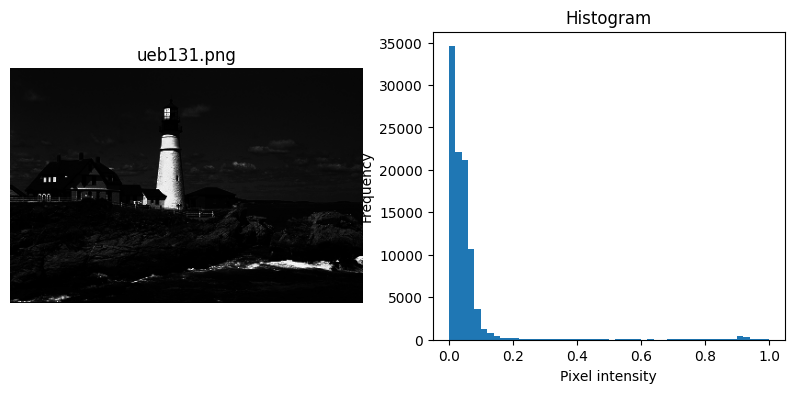

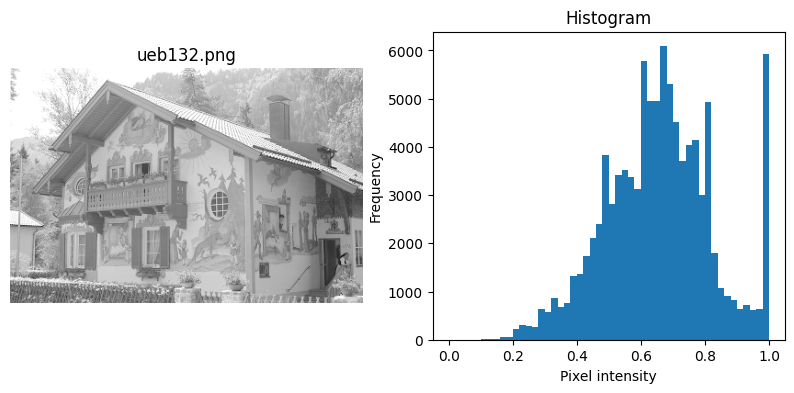

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# import urllib.request # No longer needed as images are available locally

# -----------------------------
# Helper functions
# -----------------------------
def load_gray_normalized(image_path):
    img_bgr = cv2.imread(image_path)

    if img_bgr is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    img_gray = img_gray.astype(np.float32) / 255.0

    return img_gray


def normalized_to_uint8(img):
    img = np.clip(img, 0, 1)
    return (img * 255).astype(np.uint8)


def display_with_hist(img, title="Image"):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    ax[0].imshow(img, cmap="gray", vmin=0, vmax=1)
    ax[0].set_title(title)
    ax[0].axis("off")

    ax[1].hist(img.flatten(), bins=50, range=(0, 1))
    ax[1].set_title("Histogram")
    ax[1].set_xlabel("Pixel intensity")
    ax[1].set_ylabel("Frequency")

    plt.show()


# -----------------------------
# Load and display images
# -----------------------------
# The images are already available locally from the cloned repository at data/exercise_1/
image_path_1 = "data/exercise_1/ueb131.png"
image_path_2 = "data/exercise_1/ueb132.png"

# Load the images
img_1 = load_gray_normalized(image_path_1)
img_2 = load_gray_normalized(image_path_2)

# Display images with histograms
display_with_hist(img_1, title="ueb131.png")
display_with_hist(img_2, title="ueb132.png")

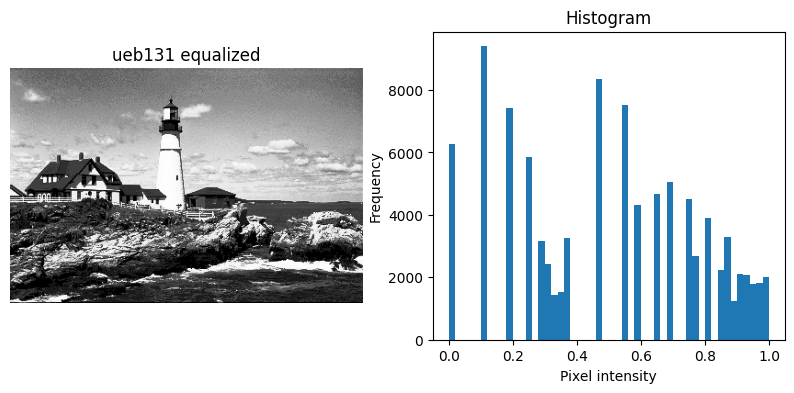

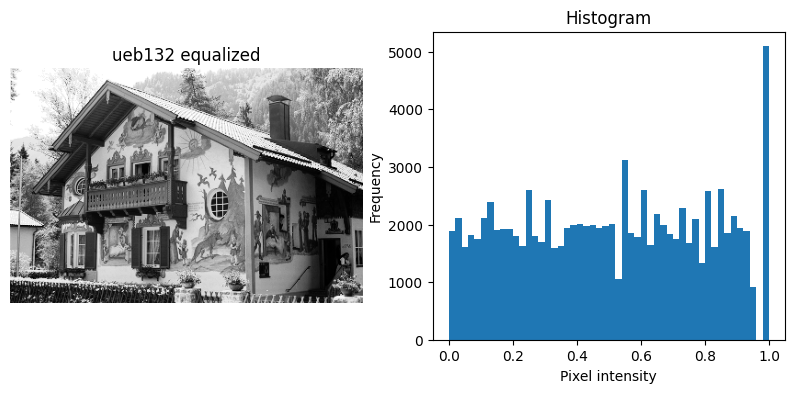

In [26]:
# TODO: convert images to uint8

img1_uint8 = normalized_to_uint8(img1)
img2_uint8 = normalized_to_uint8(img2)
# equalize histogram and display

img1_eq = cv2.equalizeHist(img1_uint8)
img2_eq = cv2.equalizeHist(img2_uint8)

# Convert back to [0,1] for display
img1_eq = img1_eq.astype(np.float32) / 255.0
img2_eq = img2_eq.astype(np.float32) / 255.0

display_with_hist(img1_eq, "ueb131 equalized")
display_with_hist(img2_eq, "ueb132 equalized")

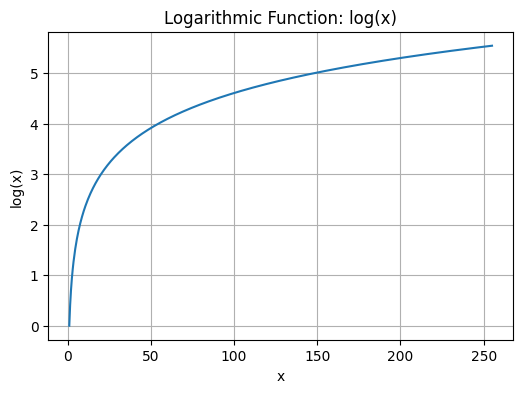

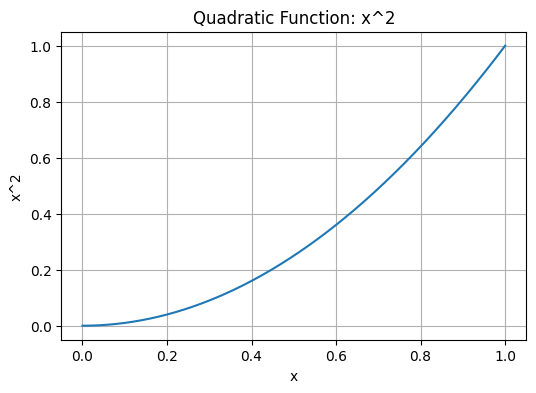

In [27]:
# TODO: display logarithmic function

x_log = np.linspace(1, 255, 500)

plt.figure(figsize=(6,4))
plt.plot(x_log, np.log(x_log))
plt.title("Logarithmic Function: log(x)")
plt.xlabel("x")
plt.ylabel("log(x)")
plt.grid()
plt.show()


# TODO: display quadratic function

x = np.linspace(0, 1, 500)

plt.figure(figsize=(6,4))
plt.plot(x, x**2)
plt.title("Quadratic Function: x^2")
plt.xlabel("x")
plt.ylabel("x^2")
plt.grid()
plt.show()

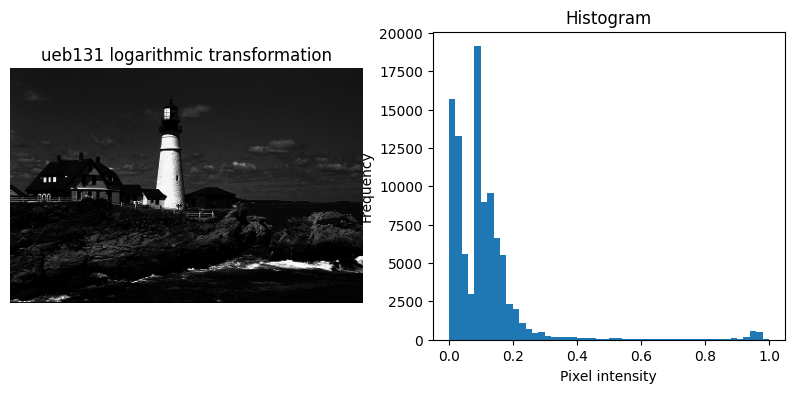

In [28]:
# TODO: transform and display ueb131.png

# ueb131 is underexposed -> brighten it

img1_log = np.log1p(5 * img1) / np.log1p(5)

display_with_hist(img1_log, "ueb131 logarithmic transformation")

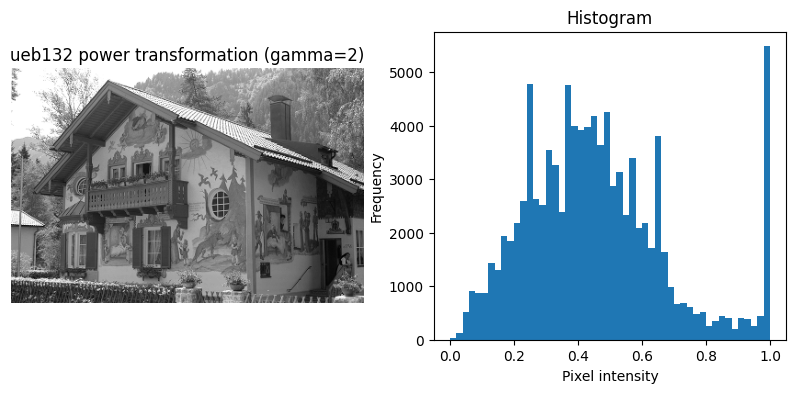

In [29]:
# TODO: transform and display ueb132.png

# ueb132 is overexposed -> darken it

img2_power = img2 ** 2.0

display_with_hist(img2_power, "ueb132 power transformation (gamma=2)")
